In [1]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Our five-stock portfolio
tickers = ["AAPL", "MSFT", "JPM", "GS", "BLK"]

# S&P 500 index
benchmark = "^GSPC"

all_tickers = tickers + [benchmark]

data = yf.download(
    all_tickers,
    start="2025-09-22",
    end="2026-09-22",
    auto_adjust=True,
    progress=False
)

prices = data["Close"].dropna()

display(prices.head())
print("Trading days:", len(prices))

Ticker,AAPL,BLK,GS,JPM,MSFT,^GSPC
Date,,,,,,
2025-09-22,255.137512,1112.436523,790.021606,306.575012,510.251892,6693.750000
2025-09-23,253.493607,1108.069946,790.766968,306.869354,505.074432,6656.919922
2025-09-24,251.381409,1104.378784,777.144836,307.536621,505.986908,6637.970215
2025-09-25,255.924622,1123.284790,779.429993,307.566040,502.892395,6604.720215
2025-09-26,254.519821,1132.253052,787.030396,310.127014,507.286194,6643.700195


Trading days: 251


In [2]:

# Calculate daily percentage returns
returns = prices.pct_change().dropna()

# Portfolio weights
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

# Daily portfolio returns
portfolio_returns = returns[tickers] @ weights

# Daily S&P 500 returns
market_returns = returns[benchmark]

comparison = pd.DataFrame({
    "Portfolio": portfolio_returns,
    "S&P 500": market_returns
})

display((comparison.head() * 100).round(2))

,Portfolio,S&P 500
Date,,
2025-09-23,-0.37,-0.55
2025-09-24,-0.50,-0.28
2025-09-25,0.64,-0.50
2025-09-26,0.59,0.59
2025-09-29,0.39,0.26


In [3]:

market_variance = market_returns.var()

portfolio_beta = (
    portfolio_returns.cov(market_returns)
    / market_variance
)

print(f"Portfolio Beta: {portfolio_beta:.3f}")

Portfolio Beta: 1.043


In [4]:

stock_betas = {}

for ticker in tickers:
    stock_betas[ticker] = (
        returns[ticker].cov(market_returns)
        / market_variance
    )

beta_table = pd.DataFrame.from_dict(
    stock_betas,
    orient="index",
    columns=["Beta"]
)

display(beta_table.round(3))

weighted_beta = np.dot(
    beta_table["Beta"],
    weights
)

print(f"Weighted Stock Beta: {weighted_beta:.3f}")
print(f"Portfolio Beta: {portfolio_beta:.3f}")

,Beta
AAPL,0.693
MSFT,0.986
JPM,0.770
GS,1.574
BLK,1.191


Weighted Stock Beta: 1.043
Portfolio Beta: 1.043


In [5]:

risk_free_rate = 0.04
expected_market_return = 0.09

capm_expected_return = (
    risk_free_rate
    + portfolio_beta
    * (expected_market_return - risk_free_rate)
)

print(
    "CAPM Expected Return:",
    f"{capm_expected_return:.2%}"
)

CAPM Expected Return: 9.21%


In [6]:

risk_free_rate = 0.04
expected_market_return = 0.09

capm_expected_return = (
    risk_free_rate
    + portfolio_beta
    * (expected_market_return - risk_free_rate)
)

print(
    "CAPM Expected Return:",
    f"{capm_expected_return:.2%}"
)

CAPM Expected Return: 9.21%


In [7]:

trading_days = 252

annual_portfolio_return = (
    portfolio_returns.mean() * trading_days
)

annual_market_return = (
    market_returns.mean() * trading_days
)

# CAPM return using realized historical market return
historical_capm_return = (
    risk_free_rate
    + portfolio_beta
    * (annual_market_return - risk_free_rate)
)

jensens_alpha = (
    annual_portfolio_return
    - historical_capm_return
)

print(
    "Annualized Portfolio Return:",
    f"{annual_portfolio_return:.2%}"
)

print(
    "Annualized Market Return:",
    f"{annual_market_return:.2%}"
)

print(
    "Historical Jensen's Alpha:",
    f"{jensens_alpha:.2%}"
)

Annualized Portfolio Return: 15.60%
Annualized Market Return: 15.81%
Historical Jensen's Alpha: -0.71%


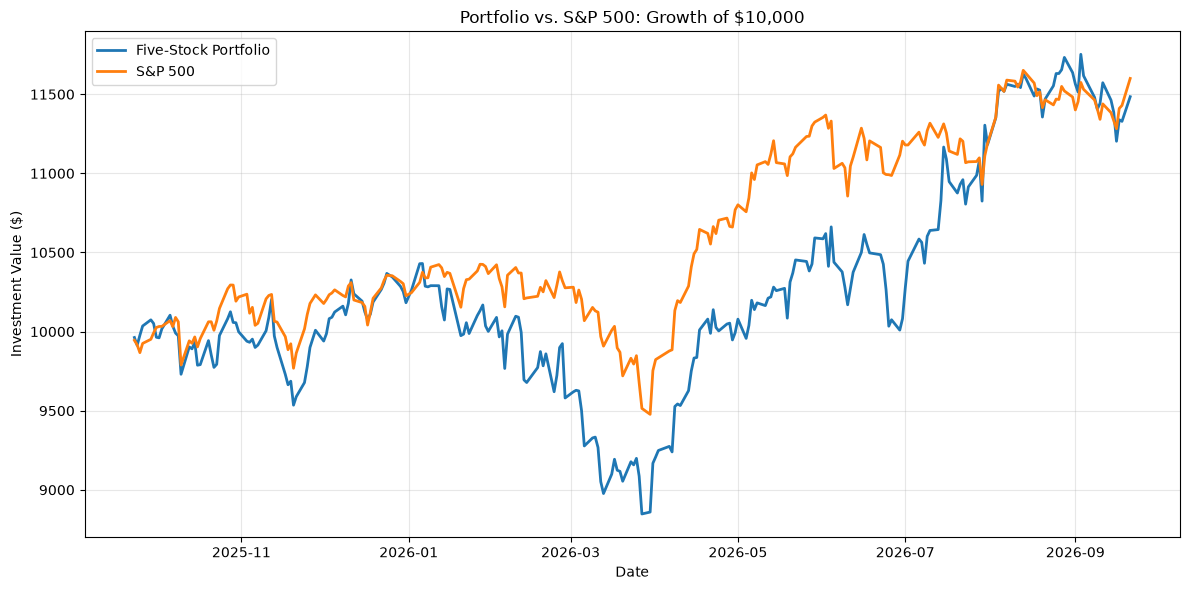

In [8]:

initial_investment = 10000

portfolio_growth = (
    1 + portfolio_returns
).cumprod()

market_growth = (
    1 + market_returns
).cumprod()

portfolio_value = (
    initial_investment * portfolio_growth
)

market_value = (
    initial_investment * market_growth
)

plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_value.index,
    portfolio_value,
    label="Five-Stock Portfolio",
    linewidth=2
)

plt.plot(
    market_value.index,
    market_value,
    label="S&P 500",
    linewidth=2
)

plt.title("Portfolio vs. S&P 500: Growth of $10,000")
plt.xlabel("Date")
plt.ylabel("Investment Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

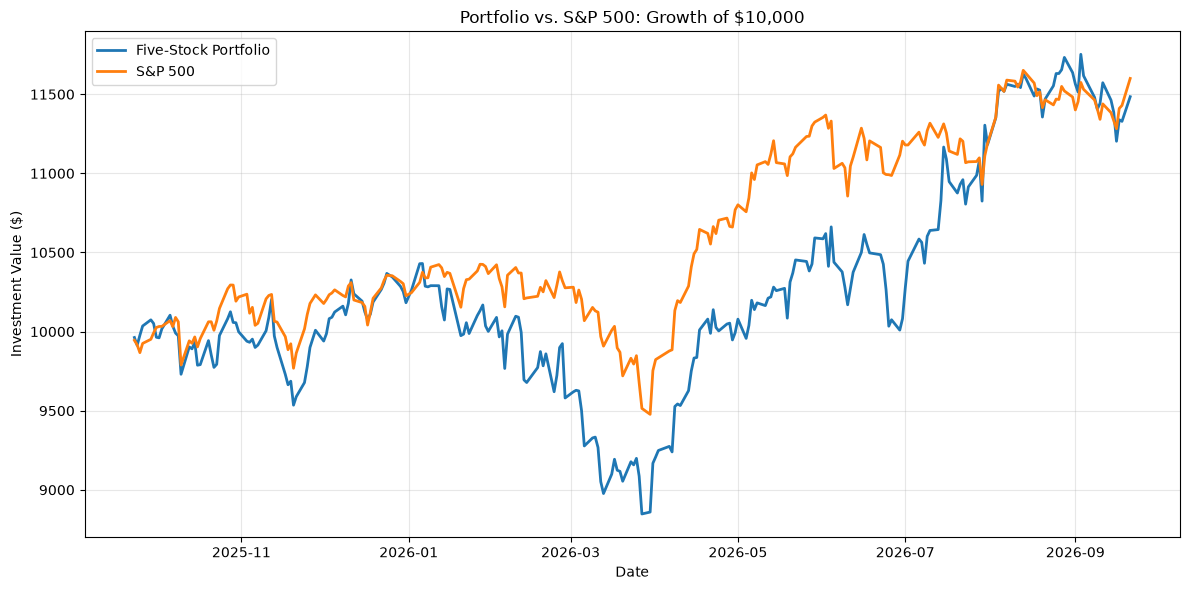

In [9]:

initial_investment = 10000

portfolio_growth = (
    1 + portfolio_returns
).cumprod()

market_growth = (
    1 + market_returns
).cumprod()

portfolio_value = (
    initial_investment * portfolio_growth
)

market_value = (
    initial_investment * market_growth
)

plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_value.index,
    portfolio_value,
    label="Five-Stock Portfolio",
    linewidth=2
)

plt.plot(
    market_value.index,
    market_value,
    label="S&P 500",
    linewidth=2
)

plt.title("Portfolio vs. S&P 500: Growth of $10,000")
plt.xlabel("Date")
plt.ylabel("Investment Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:

# Daily active return
active_returns = (
    portfolio_returns - market_returns
)

# Annualized tracking error
tracking_error = (
    active_returns.std() * np.sqrt(252)
)

# Annualized arithmetic active return
annual_active_return = (
    active_returns.mean() * 252
)

information_ratio = (
    annual_active_return / tracking_error
    if tracking_error > 0
    else np.nan
)

print(
    "Annualized Active Return:",
    f"{annual_active_return:.2%}"
)

print(
    "Tracking Error:",
    f"{tracking_error:.2%}"
)

print(
    "Information Ratio:",
    f"{information_ratio:.2f}"
)

Annualized Active Return: -0.20%
Tracking Error: 12.15%
Information Ratio: -0.02


In [11]:

portfolio_volatility = (
    portfolio_returns.std() * np.sqrt(252)
)

portfolio_sharpe = (
    (annual_portfolio_return - risk_free_rate)
    / portfolio_volatility
)

portfolio_cumulative_return = (
    portfolio_growth.iloc[-1] - 1
)

market_cumulative_return = (
    market_growth.iloc[-1] - 1
)

summary = pd.DataFrame({
    "Metric": [
        "Portfolio Beta",
        "CAPM Expected Return",
        "Historical Jensen's Alpha",
        "Portfolio Cumulative Return",
        "S&P 500 Cumulative Return",
        "Portfolio Annualized Volatility",
        "Portfolio Sharpe Ratio",
        "Tracking Error",
        "Information Ratio"
    ],
    "Value": [
        f"{portfolio_beta:.3f}",
        f"{capm_expected_return:.2%}",
        f"{jensens_alpha:.2%}",
        f"{portfolio_cumulative_return:.2%}",
        f"{market_cumulative_return:.2%}",
        f"{portfolio_volatility:.2%}",
        f"{portfolio_sharpe:.2f}",
        f"{tracking_error:.2%}",
        f"{information_ratio:.2f}"
    ]
})

display(summary)

,Metric,Value
0,Portfolio Beta,1.043
1,CAPM Expected Return,9.21%
2,Historical Jensen's Alpha,-0.71%
3,Portfolio Cumulative Return,14.84%
4,S&P 500 Cumulative Return,16.00%
5,Portfolio Annualized Volatility,18.20%
6,Portfolio Sharpe Ratio,0.64
7,Tracking Error,12.15%
8,Information Ratio,-0.02
